# Inter-amino Acid Distances Analysis

**Dataset: StarPep (sequences from 10 to 100 amino acids)**

In [1]:
from utils.plotting import boxplot, histogram
from utils.distances_database_manager import get_distances, get_and_pivot_distances, get_data_with_max_distance
import dask.dataframe as dd
import pandas as pd
from IPython.display import display, Markdown

In [2]:
# paths
database_path = '../data_parquet_starpep/'
base_path = '../output/StarPep/PaperNew/2024-12-23T15.40.45-Data_Ingestion/Analysis/'
output_path = './output/graphics/'

**Distances functions:** Euclidean, Angular Separation, Bhattacharyya, Canberra, Clark, Lance Williams, Soergel

### Statistics

In [3]:
statistics = pd.read_csv(base_path + 'Sequence_Inter_Amino_Acid_Distances-Statistics.csv')
statistics

,distance_function,count,mean,std,min,p25,p50,p75,max,skewness,kurtosis
0,euclidean,25688946,20.126474,13.689747,7.187549e-01,10.283634,16.613239,26.241980,254.056279,1.542797,6.937100
1,canberra,25688946,1.085541,0.597095,1.253596e-02,0.615481,1.014184,1.471174,3.000000,0.588522,2.858140
2,lance_williams,25688946,0.339796,0.203929,5.685703e-03,0.178902,0.304133,0.465998,1.000000,0.750031,3.041840
3,clark,25688946,0.707474,0.361186,1.008155e-02,0.416101,0.681320,0.983046,1.732051,0.312449,2.366295
4,soergel,25688946,0.474613,0.217372,1.130712e-02,0.303506,0.466414,0.635742,1.000000,0.171448,2.229505
5,bhattacharyya,25688946,2.737850,1.620385,9.118815e-02,1.515764,2.430412,3.645232,20.357421,1.043045,4.339510
6,angular_separation,25688946,0.131011,0.164412,2.814799e-09,0.018027,0.065390,0.179948,1.000000,1.999451,7.267553


### Distributions

**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*) 

<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>

<br>*Statistics*

,distance_function,count,mean,std,min,p25,p50,p75,max,skewness,kurtosis
0,euclidean,25688946,20.126474,13.689747,0.718755,10.283634,16.613239,26.241980,254.056279,1.542797,6.93710
1,bhattacharyya,25688946,2.737850,1.620385,0.091188,1.515764,2.430412,3.645232,20.357421,1.043045,4.33951


<br>*Histograms: Euclidean, Bhattacharyya*

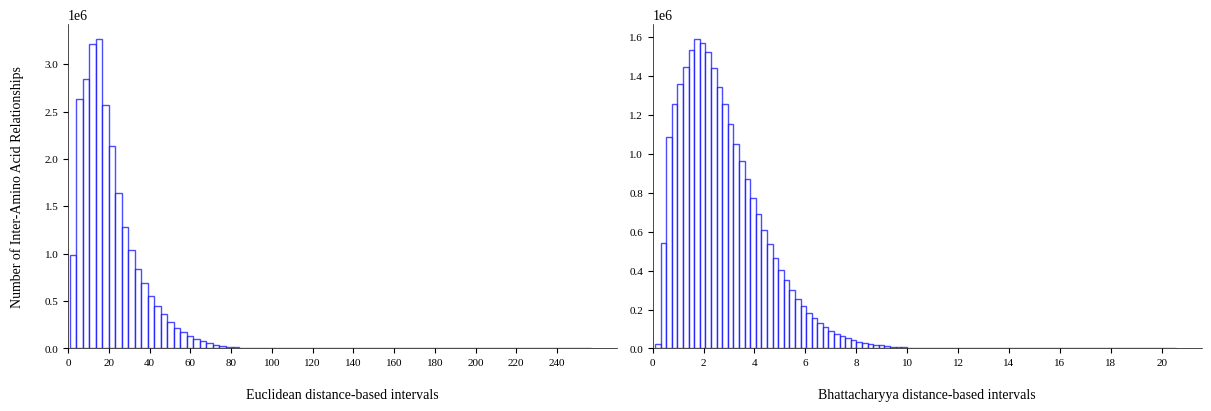

<br>*Histogram: Euclidean*

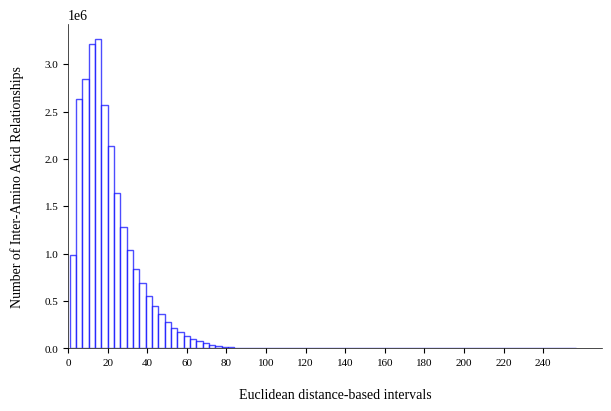

<br>*Histogram: Bhattacharyya*

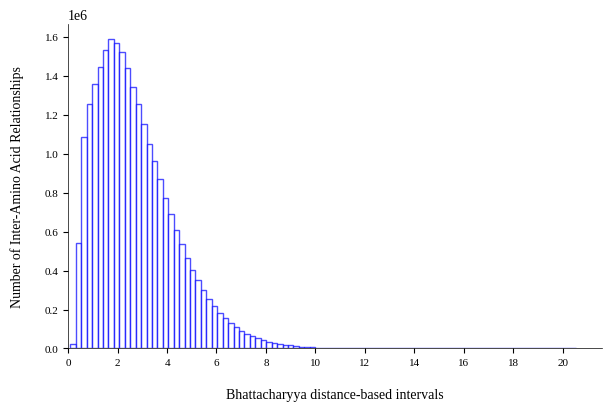

<br>*Boxplots: Euclidean, Bhattacharyya*

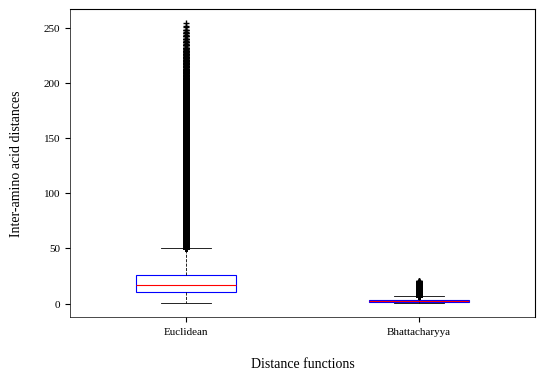

In [4]:
# distance functions 
distance_functions = ['euclidean', 'bhattacharyya']

# section name
display(Markdown("<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>"))

# statistics
display(Markdown("<br>*Statistics*"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histogram
distances = get_distances(database_path, distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Euclidean distance-based intervals', 'Bhattacharyya distance-based intervals']
bin_width = [3.2, 0.22]
x_axis_step = [20, 2]

display(Markdown("<br>*Histograms: Euclidean, Bhattacharyya*"))
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, output=f'{output_path}histogram-inter_amino_acid_distances-eu-ba')
plt.show()

display(Markdown("<br>*Histogram: Euclidean*"))
plt = histogram(distances['euclidean'], x_labels[0], y_label, bin_width=bin_width[0], x_axis_step=x_axis_step[0], output=f'{output_path}histogram-inter_amino_acid_distances-eu')
plt.show()

display(Markdown("<br>*Histogram: Bhattacharyya*"))
plt = histogram(distances['bhattacharyya'], x_labels[1], y_label, bin_width=bin_width[1], x_axis_step=x_axis_step[1], output=f'{output_path}histogram-inter_amino_acid_distances-ba')
plt.show()

del distances, plt

# boxplot
distances = get_and_pivot_distances(database_path, distance_functions)

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = f'{output_path}boxplot-inter_amino_acid_distances-eu_ba'
y_lim=(-1, 240)

display(Markdown("<br>*Boxplots: Euclidean, Bhattacharyya*"))
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

<br>*Boxplot (Euclidean, Bhattacharyya) with Maximum Angular Separation Distance*

*Sequence*: MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVSLRPIGASCRDDSECITRLCRKRRCSLSVAQE

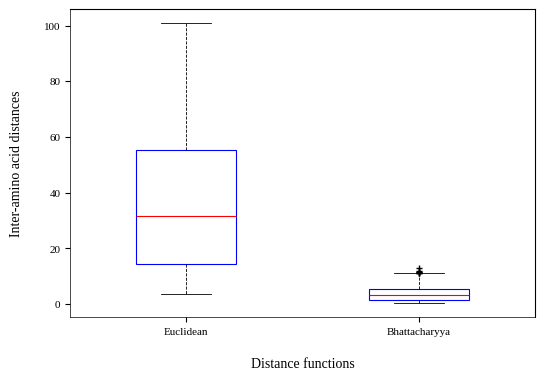

In [5]:
# boxplot (Euclidean, Bhattacharyya) with maximun Angular Separation distance
# sequence: MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVSLRPIGASCRDDSECITRLCRKRRCSLSVAQE

result = get_data_with_max_distance(database_path, distance_function='angular_separation')
sequence = result['sequence'].iloc[0]

distances = get_and_pivot_distances(database_path, distance_functions, sequence)

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = f'{output_path}boxplot-inter_amino_acid_distances-eu_ba-seq_with_max_as_dist'
y_lim=(-1, 240)

display(Markdown("<br>*Boxplot (Euclidean, Bhattacharyya) with Maximum Angular Separation Distance*"))
display(Markdown(f"*Sequence*: {sequence}"))
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

<br>*Boxplot (Euclidean, Bhattacharyya) with Maximum Euclidean Distance*

*Sequence*: RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPKPIPRPLPLPRPRPRRIPRPLPLPRPRPRPIPRPLPLPQPQPSPIPRPL

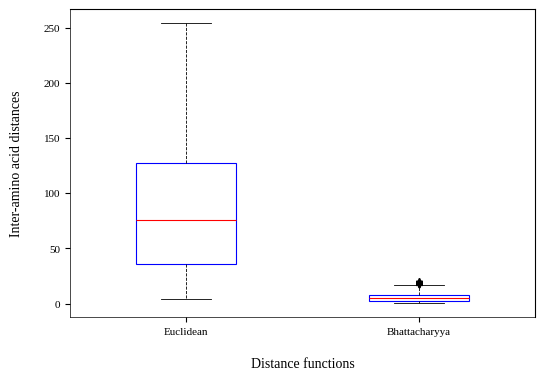

In [6]:
# boxplot (Euclidean, Bhattacharyya) with maximun Euclidean distance
# sequence:  RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPKPIPRPLPLPRPRPRRIPRPLPLPRPRPRPIPRPLPLPQPQPSPIPRPL
result = get_data_with_max_distance(database_path, distance_function='euclidean')
sequence = result['sequence'].iloc[0]

distances = get_and_pivot_distances(database_path, distance_functions, sequence)

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = f'{output_path}boxplot-inter_amino_acid_distances-eu_ba-seq_with_max_eu_dist'
y_lim=(-1, 240)

display(Markdown("<br>*Boxplot (Euclidean, Bhattacharyya) with Maximum Euclidean Distance*"))
display(Markdown(f"*Sequence*: {sequence}"))
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)

<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>

<br>*Statistics*

,distance_function,count,mean,std,min,p25,p50,p75,max,skewness,kurtosis
0,canberra,25688946,1.085541,0.597095,0.012536,0.615481,1.014184,1.471174,3.000000,0.588522,2.858140
1,clark,25688946,0.707474,0.361186,0.010082,0.416101,0.681320,0.983046,1.732051,0.312449,2.366295


<br>*Histograms: Canberra, Clark*

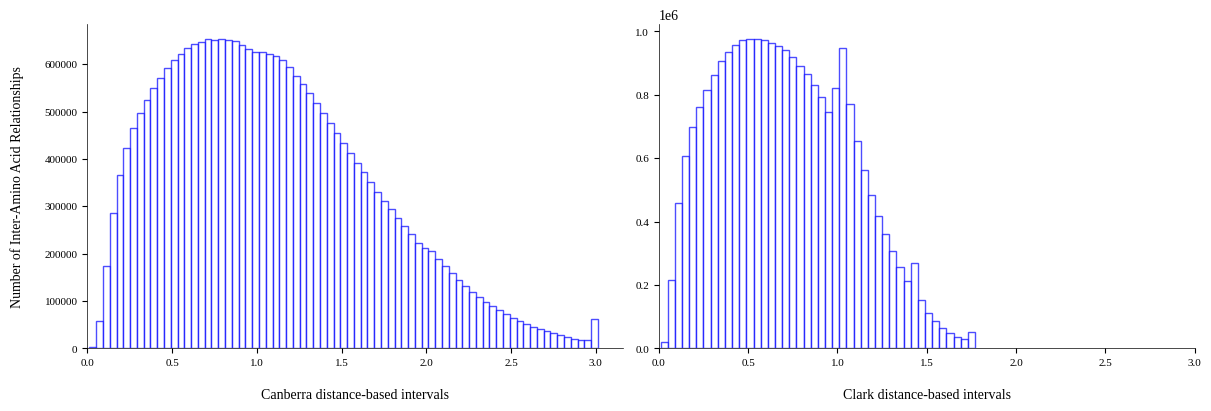

<br>*Histogram: Canberra*

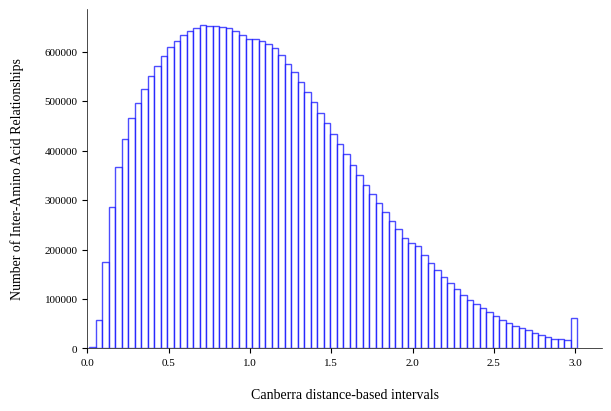

<br>*Histogram: Clark*

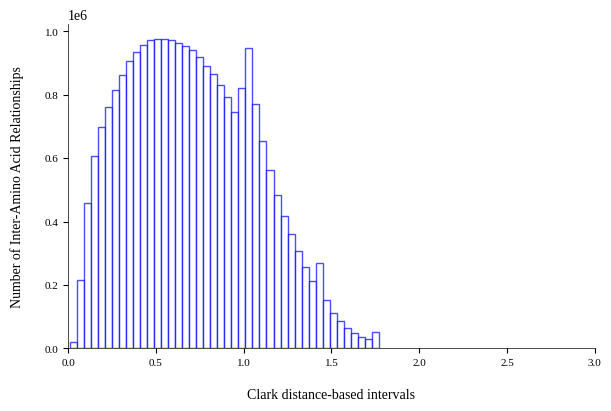

<br>*Boxplots: Canberra, Clark*

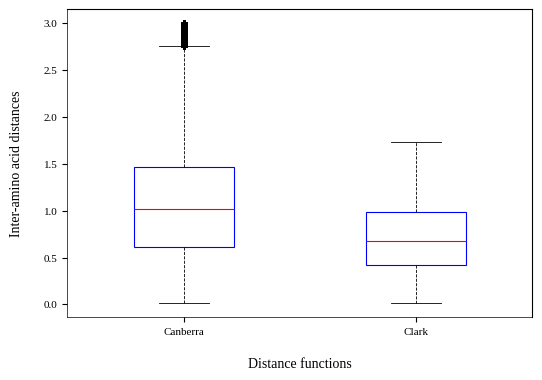

In [7]:
# distance functions
distance_functions = ['canberra', 'clark']

# section name
display(Markdown("<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>"))

# statistics
display(Markdown("<br>*Statistics*"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = get_distances(database_path, distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Canberra distance-based intervals', 'Clark distance-based intervals']
bin_width = 0.04
x_axis_step = 0.5

display(Markdown("<br>*Histograms: Canberra, Clark*"))
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=f'{output_path}histogram-inter_amino_acid_distances-ca-cl')
plt.show()

display(Markdown("<br>*Histogram: Canberra*"))
plt = histogram(distances['canberra'], x_labels[0], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=f'{output_path}histogram-inter_amino_acid_distances-ca')
plt.show()

display(Markdown("<br>*Histogram: Clark*"))
plt = histogram(distances['clark'], x_labels[1], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=f'{output_path}histogram-inter_amino_acid_distances-cl')
plt.show()

del distances, plt

# boxplot
distances = get_and_pivot_distances(database_path, distance_functions)

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Canberra', 'Clark']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = f'{output_path}boxplot-inter_amino_acid_distances-ca_cl'
y_lim=(-1, 240)

display(Markdown("<br>*Boxplots: Canberra, Clark*"))
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)

<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>

<br>*Statistics*

,distance_function,count,mean,std,min,p25,p50,p75,max,skewness,kurtosis
0,lance_williams,25688946,0.339796,0.203929,5.685703e-03,0.178902,0.304133,0.465998,1.0,0.750031,3.041840
1,soergel,25688946,0.474613,0.217372,1.130712e-02,0.303506,0.466414,0.635742,1.0,0.171448,2.229505
2,angular_separation,25688946,0.131011,0.164412,2.814799e-09,0.018027,0.065390,0.179948,1.0,1.999451,7.267553


<br>*Histograms: Angular Separation, Lance Williams, Soergel*

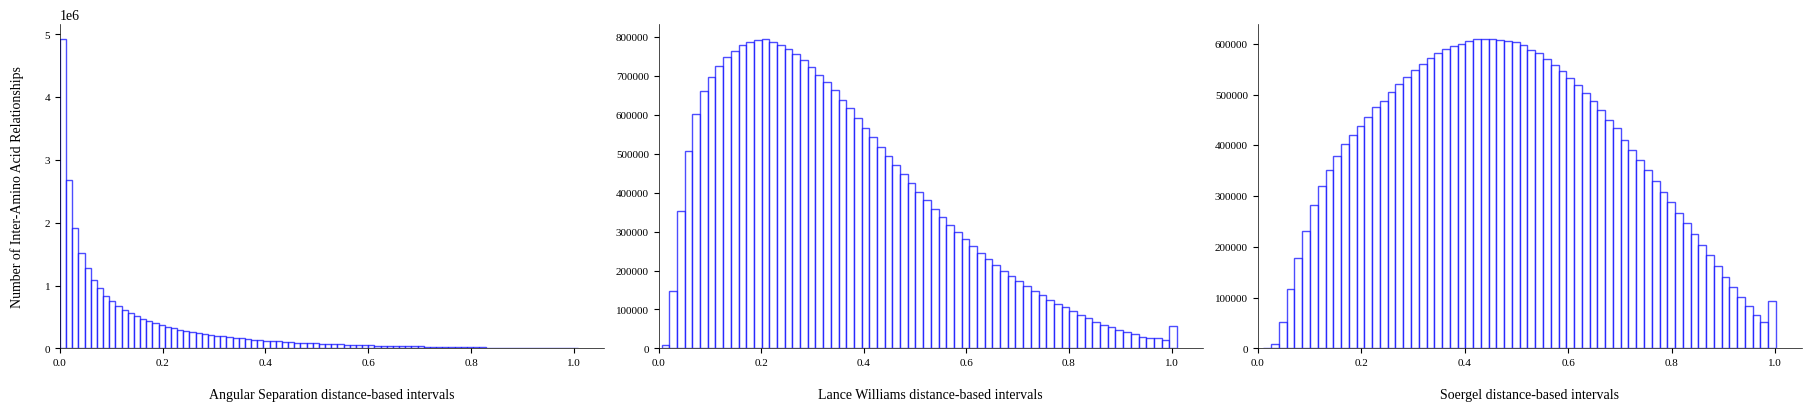

<br>*Histogram: Angular Separation*

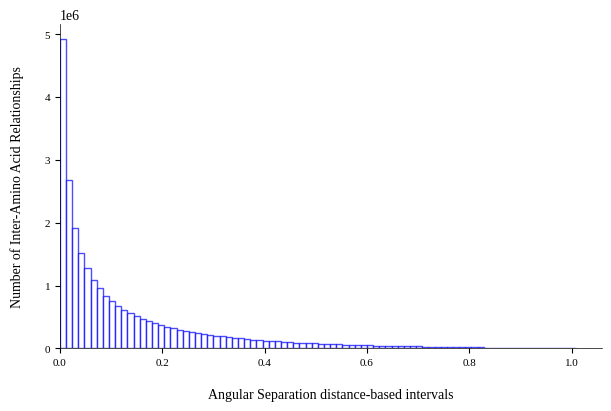

<br>*Histogram: Lance Williams*

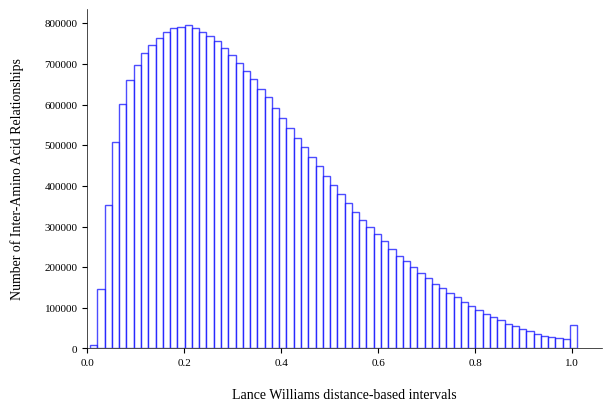

<br>*Histogram: Soergel*

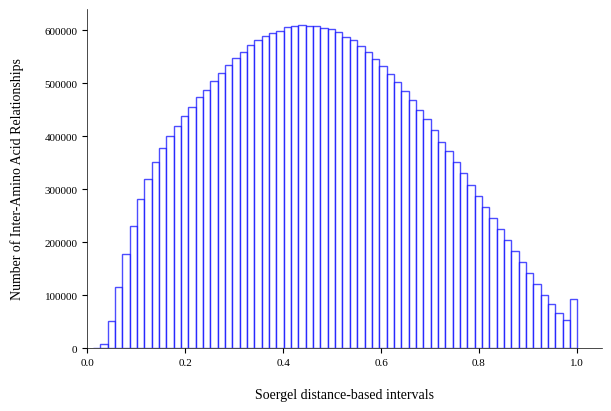

<br>*Boxplots: Angular Separation, Lance Williams, Soergel*

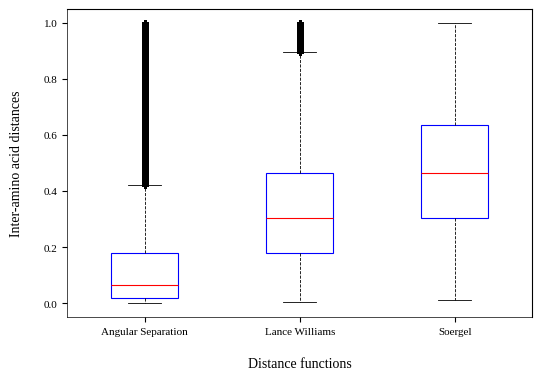

In [8]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# section name
display(Markdown("<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>"))

# statistics
display(Markdown("<br>*Statistics*"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = get_distances(database_path, distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based intervals', 'Lance Williams distance-based intervals', 'Soergel distance-based intervals']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2

display(Markdown("<br>*Histograms: Angular Separation, Lance Williams, Soergel*"))
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=f'{output_path}histogram-inter_amino_acid_distances-as-lw-so')
plt.show()

display(Markdown("<br>*Histogram: Angular Separation*"))
plt = histogram(distances['angular_separation'], x_labels[0], y_label, bin_width[0], x_axis_step, x_axis_max=1, output=f'{output_path}histogram-inter_amino_acid_distances-as')
plt.show()

display(Markdown("<br>*Histogram: Lance Williams*"))
plt = histogram(distances['lance_williams'], x_labels[1], y_label, bin_width[1], x_axis_step, x_axis_max=1, output=f'{output_path}histogram-inter_amino_acid_distances-lw')
plt.show()

display(Markdown("<br>*Histogram: Soergel*"))
plt = histogram(distances['soergel'], x_labels[2], y_label, bin_width[2], x_axis_step, x_axis_max=1, output=f'{output_path}histogram-inter_amino_acid_distances-so')
plt.show()

del distances, plt

# boxplot
distances = get_and_pivot_distances(database_path, distance_functions)

x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = f'{output_path}boxplot-inter_amino_acid_distances-as_lw_so'
y_lim=(-1, 240)

display(Markdown("<br>*Boxplots: Angular Separation, Lance Williams, Soergel*"))
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

<br>*Histograms (vertical): Angular Separation, Lance Williams, Soergel*

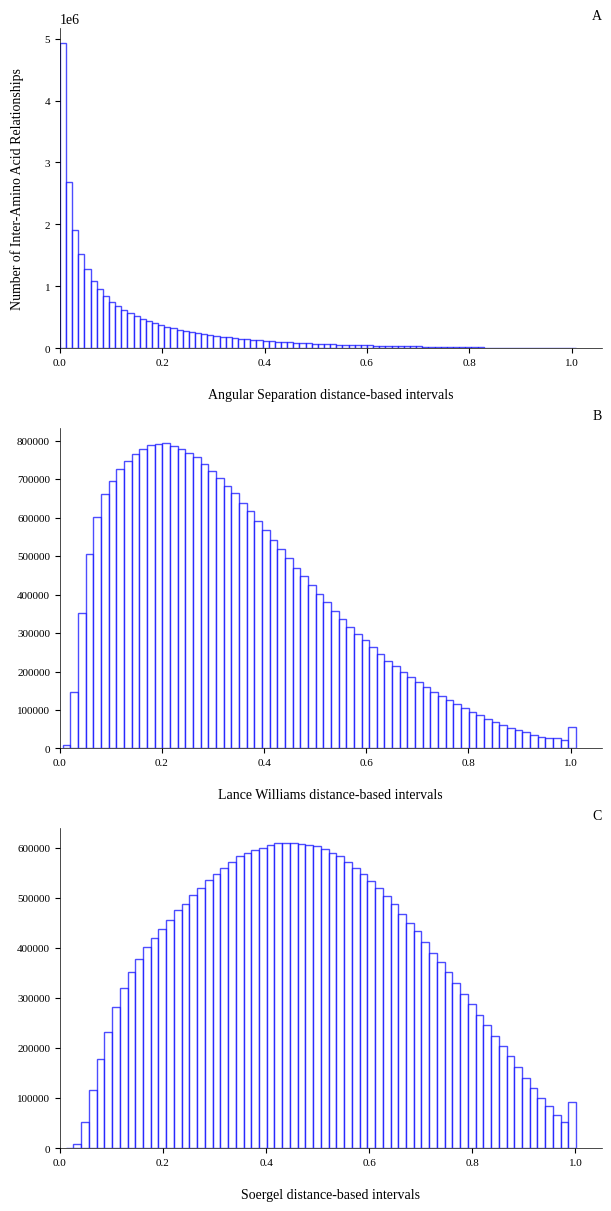

In [9]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# histograms
distances = get_distances(database_path, distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based intervals', 'Lance Williams distance-based intervals', 'Soergel distance-based intervals']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2
output=f'{output_path}histogram-inter_amino_acid_distances-as-lw-so-vertical'
titles=['A', 'B', 'C']

display(Markdown("<br>*Histograms (vertical): Angular Separation, Lance Williams, Soergel*"))
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output, titles=titles, n_cols=1)
plt.show()